In [ ]:
import os
import torch
from wordcloud import WordCloud
import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/DS310/Dataset/datasets/Single-Label dataset"

Mounted at /content/drive


In [ ]:
all_dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        label = file.replace("_papers.csv", "")
        df = pd.read_csv(os.path.join(folder_path, file))

        df["category"] = label

        all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)
print("Tổng số dòng:", len(merged_df))
merged_df.head()

Tổng số dòng: 12312


,title,link,date_posted,headline,source,abstract,full_story,category
0,Research Explores Workers' Response to Abusive...,https://www.sciencedaily.com/releases/2018/02/...,"February 8, 2018",Research explores workers' response to abusive...,University of Texas at Dallas,A recent study examined the damaging impact ab...,A recent Naveen Jindal School of Management st...,business_industry
1,Standing Room Only at Work,https://www.sciencedaily.com/releases/2018/02/...,"February 12, 2018",Standing room only at work,Inderscience,"The promotion of active work stations, such as...","The promotion of active work stations, such as...",business_industry
2,Who Should Be Held Responsible for the Aliso C...,https://www.sciencedaily.com/releases/2018/02/...,"February 14, 2018",Who should be held responsible for the Aliso C...,University of Southern California,A new analysis of the Aliso Canyon gas leak de...,A USC-led analysis of the Aliso Canyon gas lea...,business_industry
3,Practical Work-Related Tasks May Reduce Burnou...,https://www.sciencedaily.com/releases/2018/02/...,"February 14, 2018",Practical work-related tasks may reduce burnou...,American Friends of Tel Aviv University,A new study suggests that immediately charging...,Managers hoping to avoid employee burnout and ...,business_industry
4,Hitting Rock Bottom After Job Loss Can Be Bene...,https://www.sciencedaily.com/releases/2018/02/...,"February 27, 2018",Hitting rock bottom after job loss can be bene...,University of Notre Dame,Bottoming out as a result of job loss can be n...,"We've all heard it said, ""When you hit rock bo...",business_industry


In [ ]:
merged_df["full_story"] = merged_df["full_story"].astype(str).fillna("")
merged_df["abstract"]   = merged_df["abstract"].astype(str).fillna("")

# Lọc bỏ những dòng thực sự rỗng hoặc quá ngắn
merged_df = merged_df[merged_df["full_story"].str.len() > 100]
merged_df = merged_df[merged_df["abstract"].str.len() > 10]
merged_df = merged_df.reset_index(drop=True)

In [ ]:
# Chia train + temp (val + test)
train_df, temp_df = train_test_split(
    merged_df,
    test_size=0.2,
    stratify=merged_df["category"],
    random_state=42
)

# Chia val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["category"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 9848
Validation: 1231
Test: 1232


In [ ]:
train_df.head()

,title,link,date_posted,headline,source,abstract,full_story,category
6214,Judging Knots Throws People for a Loop,https://www.sciencedaily.com/releases/2024/12/...,"December 11, 2024",Judging knots throws people for a loop,Johns Hopkins University,"We tie our shoes, we put on neckties, we wrest...","We tie our shoes, we put on neckties, we wrest...",living_well
1708,"Using ChatGPT, Students Might Pass a Course, b...",https://www.sciencedaily.com/releases/2025/04/...,"April 22, 2025","Using ChatGPT, students might pass a course, b...",University of Illinois Grainger College of Eng...,With the assumption that students are going to...,With the assumption that students are going to...,computer_math
4323,Genetic Variant Identified That Shaped the Hum...,https://www.sciencedaily.com/releases/2024/04/...,"April 18, 2024",Genetic variant identified that shaped the hum...,Tokyo Medical and Dental University,Researchers have identified a variant in the g...,"Humans, Homo sapiens, have unique features com...",fossils_ruins
918,NaN,https://www.sciencedaily.com/releases/2024/07/...,"July 12, 2024",When to trust an AI model,Massachusetts Institute of Technology,A new technique enables huge machine-learning ...,Because machine-learning models can give false...,business_industry
10191,NaN,https://www.sciencedaily.com/releases/2025/11/...,"November 3, 2025",Ancient fish with human-like hearing stuns sci...,University of California - Berkeley,"Long ago, some saltwater fish adapted to fresh...",An artist's reconstruction of the Weberian app...,plants_animals


In [ ]:
val_df.head()

,title,link,date_posted,headline,source,abstract,full_story,category
9553,Intensifying Farmland Can Sometimes Degrade Bi...,https://www.sciencedaily.com/releases/2025/05/...,"May 4, 2025",Intensifying farmland can sometimes degrade bi...,University College London,The intensification of existing farmland can s...,The intensification of existing farmland can s...,plants_animals
5089,"Scientists Just Proved the Moai Could Walk, So...",https://www.sciencedaily.com/releases/2025/10/...,"October 8, 2025","Scientists just proved the moai could walk, so...",Binghamton University,Researchers confirmed that Rapa Nui’s moai sta...,A research team including Binghamton Universit...,fossils_ruins
10389,New Temperatures in Two Thirds of Key Tropical...,https://www.sciencedaily.com/releases/2024/10/...,"October 15, 2024",New temperatures in two thirds of key tropical...,University of Exeter,Two thirds of Key Biodiversity Areas (KBAs) in...,Two thirds of Key Biodiversity Areas (KBAs) in...,science_society
3155,Air Pollution Spikes Linked to Lower Test Scor...,https://www.sciencedaily.com/releases/2020/12/...,"December 1, 2020",Air pollution spikes linked to lower test scor...,University of Utah,More frequent exposure to air pollution spikes...,"Fine particulate matter (PM2.5), the tiny part...",education_learning
12128,Astronomers Capture Breathtaking First Look at...,https://www.sciencedaily.com/releases/2025/08/...,"August 27, 2025",Astronomers capture breathtaking first look at...,University of Galway,"WISPIT 2b, a gas giant forming around a young ...",Image of a dusty disk around a young star. Amo...,space_time


In [ ]:
test_df.head()

,title,link,date_posted,headline,source,abstract,full_story,category
5694,Why Some People Age Faster. And the 400 Genes ...,https://www.sciencedaily.com/releases/2025/08/...,"August 22, 2025",Why some people age faster. And the 400 genes ...,University of Colorado at Boulder,Researchers identified over 400 genes tied to ...,Scientists have uncovered more than 400 genes ...,health_medicine
4392,Scientists Uncover a Multibillion-Year Epic Wr...,https://www.sciencedaily.com/releases/2024/05/...,"May 31, 2024",Scientists uncover a multibillion-year epic wr...,Tokyo Institute of Technology,Life evolved from simple geochemical processes...,The origin of life on Earth has long been a my...,fossils_ruins
8851,Marfan Syndrome Increases Risk of Brain Altera...,https://www.sciencedaily.com/releases/2025/05/...,"May 16, 2025",Marfan syndrome increases risk of brain altera...,Universitat Autonoma de Barcelona,A study reveals that inflammation associated w...,A study by the Institut de Neurociències of th...,mind_brain
10860,Telemedicine May Help Reduce Use of Unnecessar...,https://www.sciencedaily.com/releases/2025/02/...,"February 24, 2025",Telemedicine may help reduce use of unnecessar...,Mass General Brigham,A research team has found that telemedicine ma...,Low-value care -- medical tests and procedures...,science_society
7967,"Lasers Just Unlocked a Hidden Side of Gold, Co...",https://www.sciencedaily.com/releases/2025/07/...,"July 19, 2025","Lasers just unlocked a hidden side of gold, co...",The Hebrew University of Jerusalem,Scientists have cracked a century-old physics ...,"Using only a blue laser and smart modulation, ...",matter_energy


## Kiểm tra dataset

In [ ]:
ds_name = 'paper'

In [ ]:
def print_shape_df(df, ds_name="df"):

    print(f"{ds_name} dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print_shape_df(train_df, ds_name +" training")
print_shape_df(test_df, ds_name +" testing")
print_shape_df(val_df, ds_name +" validation")

paper training dataset has 9848 rows and 8 columns
paper testing dataset has 1232 rows and 8 columns
paper validation dataset has 1231 rows and 8 columns


In [ ]:
def print_dfInfo(df, ds_name="df"):
    print(f"The info of {ds_name} dataset\n")
    print(df.info())

print_dfInfo(train_df, ds_name+" training")

The info of paper training dataset

<class 'pandas.core.frame.DataFrame'>
Index: 9848 entries, 6214 to 4719
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        9093 non-null   object
 1   link         9848 non-null   object
 2   date_posted  9848 non-null   object
 3   headline     9847 non-null   object
 4   source       9842 non-null   object
 5   abstract     9848 non-null   object
 6   full_story   9848 non-null   object
 7   category     9848 non-null   object
dtypes: object(8)
memory usage: 950.5+ KB
None


In [ ]:
def check_null(df, ds_name='df'):
    print(f"Null Values in each col in the {ds_name} dataset:\n")
    print(df.isnull().sum())

check_null(train_df, ds_name+" training")
print()
check_null(test_df, ds_name+" testing")
print()
check_null(val_df, ds_name+" validation")

Null Values in each col in the paper training dataset:

title          755
link             0
date_posted      0
headline         1
source           6
abstract         0
full_story       0
category         0
dtype: int64

Null Values in each col in the paper testing dataset:

title          91
link            0
date_posted     0
headline        0
source          0
abstract        0
full_story      0
category        0
dtype: int64

Null Values in each col in the paper validation dataset:

title          101
link             0
date_posted      0
headline         0
source           0
abstract         0
full_story       0
category         0
dtype: int64


## Trực quan hóa các giá trị Null

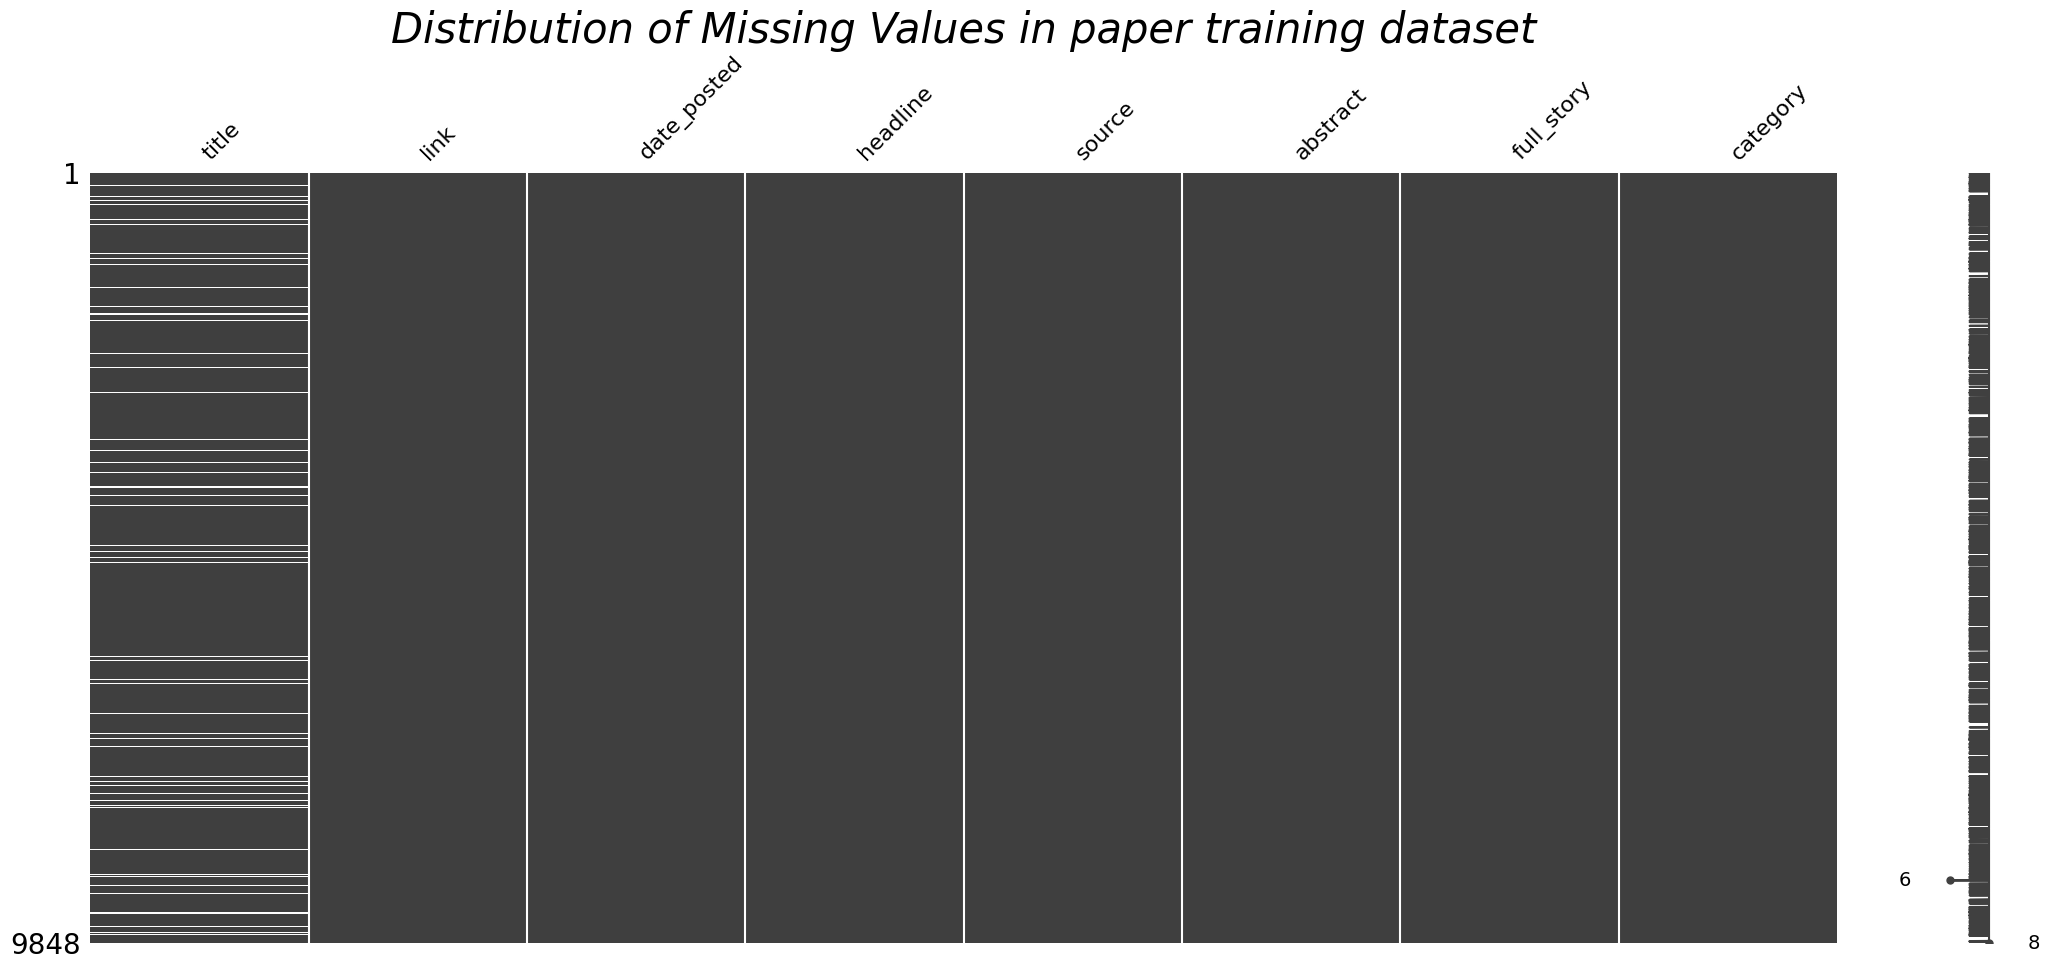

In [ ]:
def plot_miss_vals(df, ds_name="df"):
    msno.matrix(df)
    plt.title(f'Distribution of Missing Values in {ds_name} dataset', fontsize=30, fontstyle='oblique')
    plt.show()

plot_miss_vals(train_df, ds_name+" training")

→ Thường bị null ở tilte khoảng 8%

## Kiểm tra độ dài văn bản

Tính số từ

In [ ]:
df["text_word_len"] = df["full_story"].apply(lambda x: len(str(x).split()))
df["summary_word_len"] = df["abstract"].apply(lambda x: len(str(x).split()))

Tính số ký tự

In [ ]:
df["text_char_len"] = df["full_story"].apply(lambda x: len(str(x)))

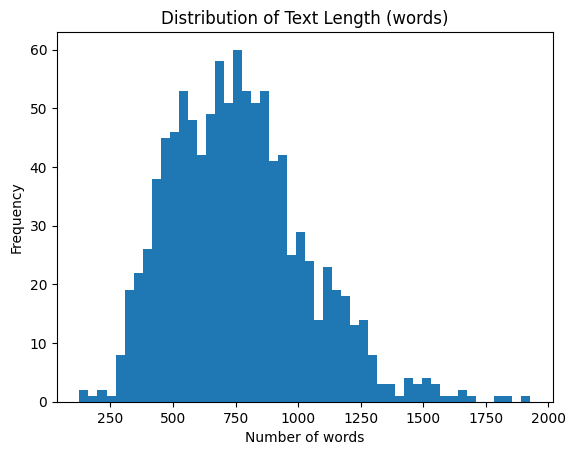

In [ ]:
plt.hist(df["text_word_len"], bins=50)
plt.title("Distribution of Text Length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Nhận xét:
- Phần lớn bài báo có độ dài: 500 – 900 từ

- Có một đuôi dài (long tail) kéo đến ~1500–1900 từ → một số bài dài bất thường

- Dạng phân phối gần giống normal (chuẩn)

→ Phải dùng chunk hoặc là model lớn hơn ví dụ LongPegasus

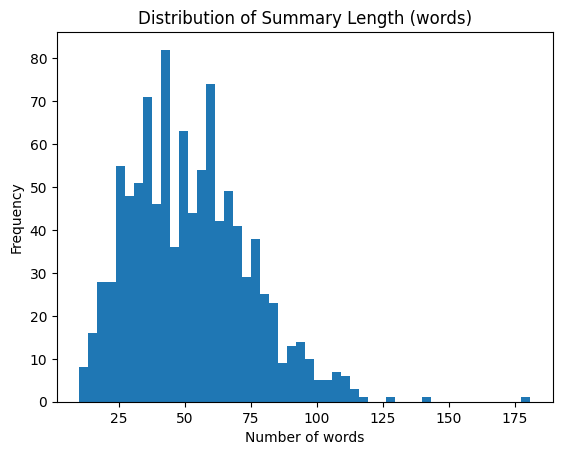

In [ ]:
plt.hist(df["summary_word_len"], bins=50)
plt.title("Distribution of Summary Length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Nhận xét:

- Phần lớn summary dài 40–70 từ

- Tập trung mạnh nhất khoảng 45–55 từ

- Một phần nhỏ dài hơn 100–150 từ

- Rất ít summary ngắn < 20 từ

Check text quá dài so với mô hình

In [ ]:
print("Texts > 1024 words:", sum(df["text_word_len"] > 1024))
print("Texts > 512 words:", sum(df["text_word_len"] > 512))

Texts > 1024 words: 162
Texts > 512 words: 833


## 7. Kiểm tra trùng lặp

In [ ]:
dup = df.duplicated(subset=["full_story"]).sum()
print("Number of duplicated texts:", dup)

Number of duplicated texts: 0


Nhận xét:

Không có trùng lặp, chứng tỏ một bài báo không thể có hai nhãn → Có thể dùng để phân loại bài báo

## Kiểm tra summary có bị copy từ text không

In [ ]:
def summary_inside_text(row):
    return str(row["abstract"]) in str(row["full_story"])

df["summary_in_text"] = df.apply(summary_inside_text, axis=1)
df["summary_in_text"].mean()

np.float64(0.12852969814995133)

Nhận xét:

Chỉ có khoảng 12.85% bài báo là có phần abstract được chép nguyên văn vào trong nội dung full_story. 87% còn lại thì abstract được viết lại, tóm tắt, hoặc chỉnh sửa khác đi so với nội dung chính.

## WordCloud

Text WordCloud

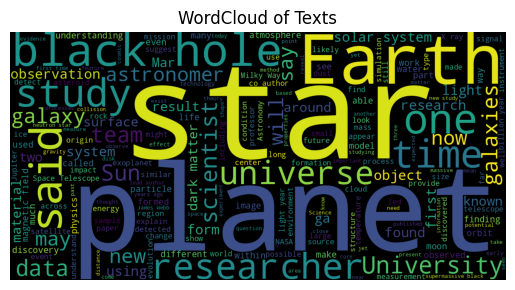

In [ ]:
text_wc = WordCloud(width=1200, height=600).generate(" ".join(df["full_story"].values))
plt.imshow(text_wc)
plt.axis("off")
plt.title("WordCloud of Texts")
plt.show()

Summary WordCloud

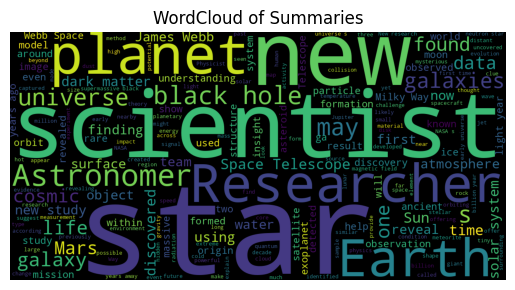

In [ ]:
summary_wc = WordCloud(width=1200, height=600).generate(" ".join(df["abstract"].values))
plt.imshow(summary_wc)
plt.axis("off")
plt.title("WordCloud of Summaries")
plt.show()

## Kiểm tra phân bố độ dài summary vs text

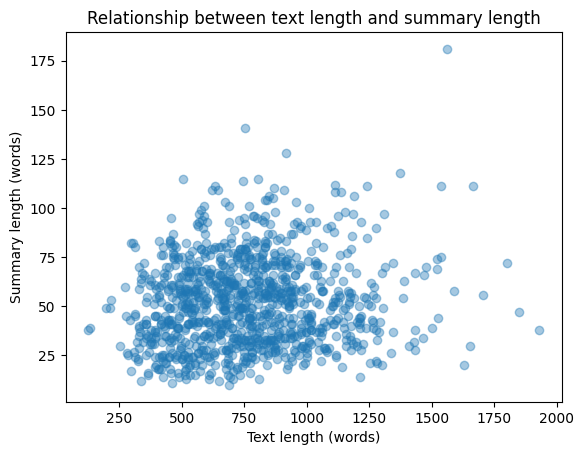

In [ ]:
plt.scatter(df["text_word_len"], df["summary_word_len"], alpha=0.4)
plt.xlabel("Text length (words)")
plt.ylabel("Summary length (words)")
plt.title("Relationship between text length and summary length")
plt.show()

Nhận xét:
Biểu đồ này là bằng chứng trực quan rõ ràng nhất cho thấy chất lượng abstract rất không đồng đều và phần lớn là viết lại chứ không copy nguyên văn.

## So sánh độ dài Abstract và Full Text

In [ ]:
merged_df["abstract_len"] = merged_df["abstract"].astype(str).apply(lambda x: len(x.split()))
merged_df["text_len"] = merged_df["full_story"].astype(str).apply(lambda x: len(x.split()))

print(merged_df[["abstract_len", "text_len"]].describe())

       abstract_len      text_len
count  12311.000000  12311.000000
mean      48.980993    676.118431
std       22.174069    245.717368
min        7.000000    115.000000
25%       31.000000    497.000000
50%       47.000000    639.000000
75%       63.000000    808.000000
max      181.000000   2490.000000


In [ ]:
merged_df["abstract_ratio"] = merged_df["abstract_len"] / merged_df["text_len"]
print(merged_df["abstract_ratio"].describe())

count    12311.000000
mean         0.080247
std          0.044835
min          0.008734
25%          0.047710
50%          0.071527
75%          0.102401
max          0.403909
Name: abstract_ratio, dtype: float64


# So sánh độ dài Title và Full Text

In [ ]:
merged_df["title_len"] = merged_df["title"].astype(str).apply(lambda x: len(x.split()))
merged_df["text_len"] = merged_df["full_story"].astype(str).apply(lambda x: len(x.split()))

print(merged_df[["title_len", "text_len"]].describe())

          title_len      text_len
count  12311.000000  12311.000000
mean       9.303144    676.118431
std        3.648249    245.717368
min        1.000000    115.000000
25%        8.000000    497.000000
50%        9.000000    639.000000
75%       11.000000    808.000000
max       26.000000   2490.000000


Kết luận: ABSTRACT chỉ bằng khoảng 1–2% độ dài toàn bài

# Tính tỷ lệ “compress ratio”

In [ ]:
merged_df["ratio"] = merged_df["title_len"] / merged_df["text_len"]
print(merged_df["ratio"].describe())

count    12311.000000
mean         0.015569
std          0.008481
min          0.000473
25%          0.010254
50%          0.014682
75%          0.019924
max          0.114833
Name: ratio, dtype: float64


Kết luận: TITLE chỉ bằng khoảng 1–2% độ dài toàn bài

## Lưu dataset

In [ ]:
merged_df.to_csv("merged.csv", index=False, encoding="utf-8-sig")

train_df.to_csv("train.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("val.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("test.csv", index=False, encoding="utf-8-sig")